In [5]:
# Install all required packages
%pip install torch torchvision torchaudio scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Imports all things in here

import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

Using: cpu
cardboard : 404 images
glass : 502 images
metal : 411 images
paper : 595 images
plastic : 483 images
trash : 137 images
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

Label test:
0
cardboard


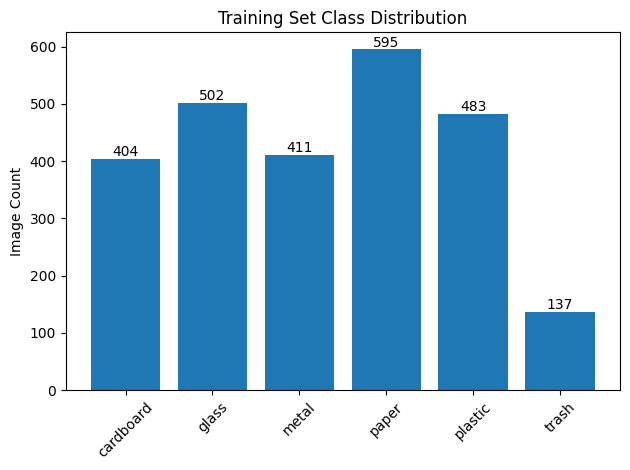

In [7]:
# Insert Dataset here (From google Drive) + GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

root = "dataset/"
for folder in os.listdir(root):
    path = os.path.join(root, folder)
    print(folder, ":", len(os.listdir(path)), "images")

dataset = datasets.ImageFolder("dataset/")
print(dataset.class_to_idx)

img, label = dataset[0]

print("\nLabel test:")
print(label)
print(dataset.classes[label])

# For graphing
counts = [len(os.listdir(os.path.join(root, cls))) for cls in dataset.classes]
bars = plt.bar(dataset.classes, counts)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center'
    )

plt.xticks(rotation=45)
plt.ylabel("Image Count")
plt.title("Training Set Class Distribution")
plt.tight_layout()

In [8]:
# Prepare Dataset

torch.manual_seed(42) # Commment this out if u want random split images test/valid

#Transform dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

#Save new augmented dataset
dataset = datasets.ImageFolder("dataset/",transform=transform)

#Split dataset
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Uncomment this 2 line for only training set and comment above
# dataset = datasets.ImageFolder("dataset/", transform=transform)
# train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

#Load dataset (Note: If u uncomment the 2 line above, unncomment this as well)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Images leak:",len(set(train_dataset.indices).intersection(set(test_dataset.indices))))
print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Images leak: 0
Train dataset size: 2021
Test dataset size: 506


In [9]:
# Prepare Model

model = models.mobilenet_v2(pretrained=True)
model = model.to(device)
model.classifier = nn.Identity()

for param in model.parameters():
    param.requires_grad = False

model.eval()

def feature_extraction(loader, model):
    all_features = []
    all_labels= []

    with torch.no_grad():
        for images, labels in loader:
            feature = model(images)
            all_features.append(feature)
            all_labels.append(labels)
    
    return torch.cat(all_features), torch.cat(all_labels)

train_features, train_labels = feature_extraction(train_loader, model)
test_features, test_labels = feature_extraction(test_loader, model)

print("Train features shape:", train_features.shape)  # (n_samples, 1280)
print("Test features shape:", test_features.shape)

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train features shape: torch.Size([2021, 1280])
Test features shape: torch.Size([506, 1280])


In [10]:
# Train
X_train = train_features.numpy()
y_train = train_labels.numpy()
X_test = test_features.numpy()
y_test = test_labels.numpy()

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds, target_names=dataset.classes))

Accuracy: 0.7648221343873518
              precision    recall  f1-score   support

   cardboard       0.84      0.81      0.82        77
       glass       0.74      0.79      0.76       105
       metal       0.80      0.77      0.78        86
       paper       0.79      0.84      0.81       116
     plastic       0.69      0.73      0.71        89
       trash       0.70      0.42      0.53        33

    accuracy                           0.76       506
   macro avg       0.76      0.73      0.74       506
weighted avg       0.76      0.76      0.76       506



In [11]:
# Eval + Result
cm = confusion_matrix(y_test,preds)
print(cm)


[[62  1  1 12  1  0]
 [ 1 83  7  2 11  1]
 [ 1  9 66  4  6  0]
 [ 6  2  3 97  4  4]
 [ 0 15  5  3 65  1]
 [ 4  2  1  5  7 14]]


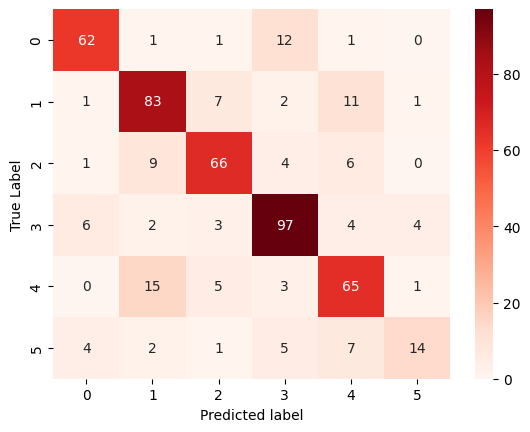

In [12]:
sns.heatmap(cm, annot=True,fmt="d", cmap="Reds")
plt.xlabel("Predicted label")
plt.ylabel("True Label")
plt.show()